In [1]:
import seaborn as sns
import pandas as pd
from pyspark.sql import Window
import pyspark.sql.functions as F
import matplotlib.pyplot as plt

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RetailRocket")
    .getOrCreate()
)

In [3]:
df_events = spark.read.csv(
    "../data/interim/events.csv",
    header=True,
    inferSchema=True
)

df_prop_1 = spark.read.csv(
    "../data/interim/item_properties_part1.csv",
    header=True,
    inferSchema=True
)

df_prop_2 = spark.read.csv(
    "../data/interim/item_properties_part2.csv",
    header=True,
    inferSchema=True
)
df_prop = df_prop_1.unionByName(df_prop_2)

In [6]:
# Pegar a última versão de cada propriedade
window_spec = Window.partitionBy("itemid", "property").orderBy("timestamp").rowsBetween(Window.unboundedPreceding, Window.unboundedFollowing)

df_prop_last = (
    df_prop
    # Aplica a função last sobre a janela para manter a ordem correta do timestamp
    .withColumn("last_value", F.last("value").over(window_spec))
    # Agrupa para remover as duplicadas e trazer o resultado final
    .groupBy("itemid", "property")
    .agg(F.last("value").alias("value"), F.last("timestamp").alias("timestamp"))
)

props = df_prop_last[
    df_prop_last['property']
    .isin([
        'categoryid',
        'available'
    ])
]

df_items = (
    props
    # 1. O 'index' vira o groupBy
    .groupBy("itemid")
    # 2. O 'columns' vira o argumento do pivot
    .pivot("property")
    # 3. O 'values' entra dentro de uma função de agregação (ex: first ou max)
    .agg(F.first("value"))
)


df_eda = df_events.join(
    df_items,
    on='itemid',
    how='left'
)

# Baseline 1 - popularity

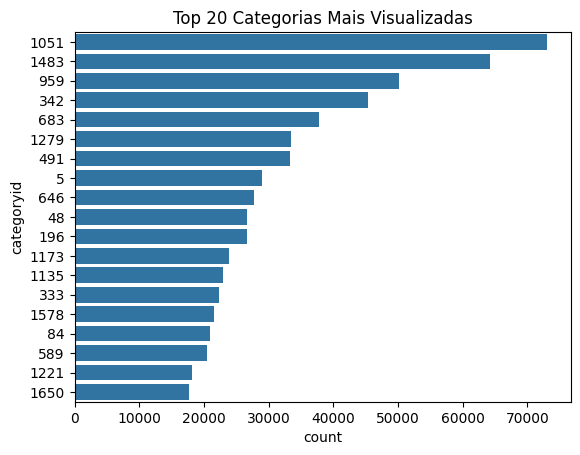

In [7]:
# Baseline 1 - popularity
views_categoria = (
    df_eda
    .filter("event='view'")
    .groupBy("categoryid")
    .count()
    .orderBy("count", ascending=False)
    .limit(20)
    .toPandas()
)

sns.barplot(
    data=views_categoria,
    y="categoryid",
    x="count"
)

plt.title("Top 20 Categorias Mais Visualizadas")
plt.show()

In [9]:
popularity = (
    df_eda
    .groupBy("itemid")
    .agg(
        F.sum(
            F.when(F.col("event") == "view", 1)
             .when(F.col("event") == "addtocart", 3)
             .when(F.col("event") == "transaction", 5)
             .otherwise(0)
        ).alias("score")
    )
    .orderBy("score", ascending=False)
)

# Top N itens — será a recomendação para qualquer usuário
top_n_items = popularity.limit(10).toPandas()
print(top_n_items)

   itemid  score
0  461686   4122
1  187946   3416
2    5411   2352
3  219512   1944
4  257040   1933
5  320130   1921
6    7943   1867
7  370653   1854
8  384302   1798
9  309778   1784


# Baseline 2 - Modelo de KNN

In [10]:
# PySpark monta a matriz, scipy faz o KNN
# 1. Agregar interações ponderadas por usuário-item
interacoes = (
    df_eda
    .withColumn("peso",
        F.when(F.col("event") == "view", 1)
         .when(F.col("event") == "addtocart", 3)
         .when(F.col("event") == "transaction", 5)
         .otherwise(0)
    )
    .groupBy("visitorid", "itemid")
    .agg(F.sum("peso").alias("peso"))
)

# 2. Filtrar usuários com pelo menos 5 interações (cold start)
usuarios_ativos = (
    interacoes
    .groupBy("visitorid")
    .count()
    .filter(F.col("count") >= 5)
    .select("visitorid")
)

interacoes_filtradas = interacoes.join(usuarios_ativos, on="visitorid")

# 3. Passar para pandas + scipy para o KNN
df_interacoes = interacoes_filtradas.toPandas()

# 4. Mapear IDs para índices contíguos
user_idx = {uid: i for i, uid in enumerate(df_interacoes["visitorid"].unique())}
item_idx = {iid: i for i, iid in enumerate(df_interacoes["itemid"].unique())}
idx_item = {i: iid for iid, i in item_idx.items()}

from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

rows = df_interacoes["visitorid"].map(user_idx)
cols = df_interacoes["itemid"].map(item_idx)
data = df_interacoes["peso"]

matrix = csr_matrix((data, (rows, cols)))

knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=21)
knn.fit(matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",21
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


# Baseline 3 - SVD

In [12]:
from sklearn.decomposition import TruncatedSVD
import numpy as np

svd = TruncatedSVD(n_components=50, random_state=42)
user_factors = svd.fit_transform(matrix)       # (n_users, 50)
item_factors = svd.components_.T               # (n_items, 50)

# Score de um usuário com todos os itens = produto interno
def recomendar_svd(user_idx_val: int, n: int = 10) -> list:
    scores = user_factors[user_idx_val] @ item_factors.T
    ja_viu = matrix[user_idx_val].nonzero()[1]
    scores[ja_viu] = -np.inf
    return np.argsort(scores)[::-1][:n].tolist()